In [1]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter
using DelimitedFiles

In [ ]:
num = 1
c = 0.5
A0,A1,A2,A3,A4 = KEB_SpatialMode.KEB_LST_ALL("Vonkarmen.txt",199,0,0.115,27.4,1,0)
nep = PEP([A0,A1,A2,A3,A4]); 
eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
eigval

1-element Vector{ComplexF64}:
 0.4666922029839594 - 0.06021178978191883im

In [8]:
Tw = 1
N_cheb = 99
Mr = 0.1
gamma = 1.4
sigma = 0.72
omega = 0.024
R = 28
c = 0.4
be = 0.07
num = 5
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,-1,2)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
# lam = - (2/3) * T
# kappa = (1/sigma) * T
# num = 5
# A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,1,0)
# nep = PEP([A0,A1,A2]); 
# eigval,eigvec = iar(nep , σ = c , neigs = num ,maxit = 500,tol=1e-10)
# eigval

([-1.3633305910839248e-25; 0.0002824809944585292; … ; -8.936913686536021e-15; -8.936913686536021e-15;;], [0.0; -0.000341179201132346; … ; -1.000000000000003; -1.000000000000003;;], [0.0; -1.565041939806863e-7; … ; -0.8844321635948295; -0.8844321635948295;;], [1.0; 1.0000005175208222; … ; 0.9999999779199694; 0.9999999779199694;;], [1.0; 0.9999994824794456; … ; 1.0000000220800311; 1.0000000220800311;;], 0.0:0.0015:15.0)

In [17]:
D2 * F

100×1 Matrix{Float64}:
 -0.9968143332217724
 -0.9990709377033578
 -0.9973357235213891
 -0.9938302088155491
 -0.9891067983966803
 -0.9829406249299873
 -0.9754718631059842
 -0.9666060342682006
 -0.9564250809531785
 -0.9448727954409822
  ⋮
  1.9411243431142565e-8
 -1.1316306067497223e-8
  6.094235482657406e-9
 -2.9369052406127934e-9
  1.2030347757894306e-9
 -3.807882427615556e-10
  7.524814033324761e-11
 -4.7044032502746444e-12
  0.0

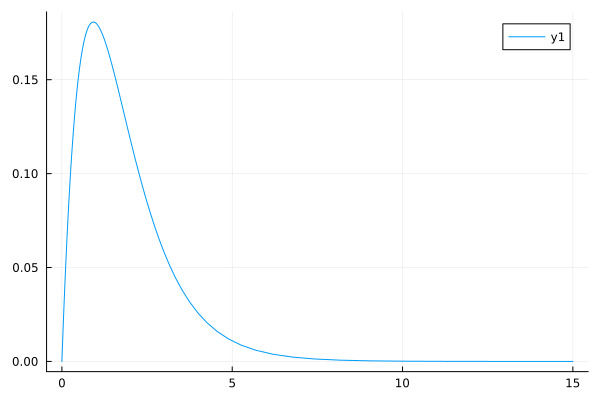

In [12]:
plot(x,F)

In [26]:
##DIRECTLY CACULATE CUR
##initial
for Tw = 1
    N_cheb = 249
    omega = 0
    Mr = 0.1
    gamma = 1.4
    sigma = 0.72
    global R = 500
    R_step = 0.25
    be1 = 0.042
    be_step = 0.0002
    c = 0.1
    num = 1
    Ro = 1
    Co = 2
    Ma = Mr/R
    
    global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,-Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num = 1
    global initial_i = []
    global initial_r = []
    global tempvec_i = [0 0 0 0]
    global tempvec_r = [0 0 0 0]
    global mode = 0
    writedlm("output_$Tw _ $Mr.dat",initial_i)
    writedlm("output_eig.dat",initial_r)
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be1,N_cheb,Ro,Co)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
    if imag(eigval[1]) < 0
        for be = be1 : -be_step : -0.1

        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
        point = filter(x ->  - 0.00012 < imag(x) < 0.0001, eigval)
        open("output_eig.dat", "a") do io
            write(io,"be=$be,eig=$eigval\n")
        end
        if point != []
            global initial_i = [omega R be imag(point)]
            global initial_r = [omega R be real(point)]
            break
        end
        end
    elseif imag(eigval[1]) > 0
        for be = be1 : be_step : 0.5

            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
            point = filter(x ->  - 0.0002 < imag(x) < 0.0002, eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if point != []
                global initial_i = [omega R be imag(point)]
                global initial_r = [omega R be real(point)]
                break
            end
        end
    end
    global total_r = initial_r
    global total_i = initial_i

# CACULATE

    for be = initial_r[1,3] +  be_step  :  be_step : 0.4

        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 1 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_1,eigvec_1 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 1 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_2,eigvec_2 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

        global mode = 1

        elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

        global mode = 2

        end
        
        if length(total_r[:,1]) > 2 

           grad = abs(( total_r[end,2] - total_r[end - 1,2] ) / ( total_r[end,3] - total_r[end - 1,3] ))
        else

           grad = 0

        end
        
        if mode == 1 



            for R = total_r[end,2] - 0 * grad * be_step  : -R_step : 0
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                pre = total_r[end,4] - im * total_i[end,4]
                eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)

                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end- 1 ,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]

                    tempvec_i = [0 0 0 0]
                    tempvec_r = [0 0 0 0]
                    
                    break
                end
                
                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                    mode = 2
                    tempvec_i = [0 0 0 0]
                    tempvec_r = [0 0 0 0]
                    break
                    
                end
            end        
        end


        if mode == 2

            for R = total_r[end,2] + 0 * grad * be_step: R_step : 600
            
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)

                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break

                end

                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                    global mode = 1
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break
                    
                end
            end
        end

        if mode == 1
            
            for R = total_r[end,2] - 0 * grad * be_step: -R_step : 0
              
                if total_i[end,3] == be

                    break

                end 

                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
     
                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break
                end
                
                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                global mode = 2
                global tempvec_i = [0 0 0 0]
                global tempvec_r = [0 0 0 0]
                    break
                    
                end

            end     
        end
 
        # if total_i[end,2]>110 && size(total_i,1)>100
        #     break
        # end
        if total_i[end,2]>total_i[end-1,2]
            break
        end

    end

    writedlm("Netwon_$Tw _$Mr _i_N=$N_cheb.dat",total_i)
    writedlm("Netwon_$Tw _$Mr _r_N=$N_cheb.dat",total_r)
    end


In [32]:
##DIRECTLY CACULATE CUR
##initial
for Tw = 1
    N_cheb = 99
    omega = 0
    Mr = 0.1
    gamma = 1.4
    sigma = 0.72
    global R = 500
    R_step = 0.1
    be1 = 0.042
    be_step = 0.0002
    c = 0.1
    num = 1
    Ro = 1
    Co = 2
    Ma = Mr/R
    
    global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,-Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num = 1
    global initial_i = []
    global initial_r = []
    global tempvec_i = [0 0 0 0]
    global tempvec_r = [0 0 0 0]
    global mode = 0
    writedlm("output_$Tw _ $Mr.dat",initial_i)
    writedlm("output_eig.dat",initial_r)
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be1,N_cheb,Ro,Co)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
    if imag(eigval[1]) < 0
        for be = be1 : -be_step : -0.1

        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
        point = filter(x ->  - 0.0001 < imag(x) < 0.0001, eigval)
        open("output_eig.dat", "a") do io
            write(io,"be=$be,eig=$eigval\n")
        end
        if point != []
            global initial_i = [omega R be imag(point)]
            global initial_r = [omega R be real(point)]
            break
        end
        end
    elseif imag(eigval[1]) > 0
        for be = be1 : be_step : 0.5

            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
            point = filter(x ->  - 0.0002 < imag(x) < 0.0002, eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if point != []
                global initial_i = [omega R be imag(point)]
                global initial_r = [omega R be real(point)]
                break
            end
        end
    end
    global total_r = initial_r
    global total_i = initial_i

# CACULATE

    for be = initial_r[1,3] +  be_step  :  be_step : 0.4

        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 1 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_1,eigvec_1 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 1 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_2,eigvec_2 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

        global mode = 1

        elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

        global mode = 2

        end
        
        if length(total_r[:,1]) > 2 

           grad = abs(( total_r[end,2] - total_r[end - 1,2] ) / ( total_r[end,3] - total_r[end - 1,3] ))
        else

           grad = 0

        end
        
        if mode == 1 



            for R = total_r[end,2] - 0 * grad * be_step  : -R_step : 0
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                pre = total_r[end,4] - im * total_i[end,4]
                eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)

                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end- 1 ,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]

                    tempvec_i = [0 0 0 0]
                    tempvec_r = [0 0 0 0]
                    
                    break
                end
                
                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                    mode = 2
                    tempvec_i = [0 0 0 0]
                    tempvec_r = [0 0 0 0]
                    break
                    
                end
            end        
        end


        if mode == 2

            for R = total_r[end,2] + 0 * grad * be_step: R_step : 600
            
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)

                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break

                end

                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                    global mode = 1
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break
                    
                end
            end
        end

        if mode == 1
            
            for R = total_r[end,2] - 0 * grad * be_step: -R_step : 0
              
                if total_i[end,3] == be

                    break

                end 

                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
     
                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break
                end
                
                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                global mode = 2
                global tempvec_i = [0 0 0 0]
                global tempvec_r = [0 0 0 0]
                    break
                    
                end

            end     
        end
 
        # if total_i[end,2]>110 && size(total_i,1)>100
        #     break
        # end
        if total_i[end,2]>total_i[end-1,2]
            break
        end

    end

    writedlm("Netwon_$Tw _$Mr _i_Ro=$Ro.dat",total_i)
    writedlm("Netwon_$Tw _$Mr _r_Ro=$Ro.dat",total_r)
    end
